**Customer Churn Analysis & Prediction**

Dataset: Telco Customer Churn

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Importing the dataset

In [6]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

This code loads the Telco Customer Churn dataset into a pandas DataFrame named `df`.

Analising the dataset

In [37]:
print(df.shape)

(7043, 22)


This shows the number of rows and columns in the dataset. There are 7043 customers and 22 features.

In [8]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [9]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
print("\nCategorical Columns:")
print(df.select_dtypes(include='object').columns)


Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


Data Cleaning

In [12]:
print("\nNumerical Columns:")
print(df.select_dtypes(include=['int64','float64']).columns)


Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [13]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


This provides a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. It's useful for identifying missing values and incorrect data types (e.g., 'TotalCharges' being an object instead of numeric).

In [14]:
# Convert TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

/tmp/ipykernel_14564/3568409879.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


This cell performs crucial data cleaning steps:
- **`TotalCharges` Conversion**: Converts the `TotalCharges` column to a numeric data type, coercing any non-numeric values to `NaN`.
- **Missing Value Imputation**: Fills the `NaN` values in `TotalCharges` (introduced by coercion) with the median of the column.
- **`Churn` Conversion**: Transforms the `Churn` column from 'Yes'/'No' to a binary numeric representation (1 for 'Yes', 0 for 'No'), making it suitable for machine learning models.

**Data Visualization**

Customer Churn Distribution

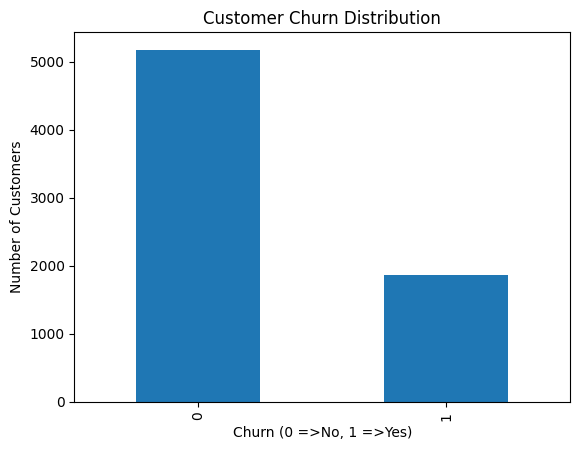

In [19]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 =>No, 1 =>Yes)")
plt.ylabel("Number of Customers")
plt.show()

This bar plot visualizes the distribution of customer churn. It shows the number of customers who churned (1) versus those who did not (0), indicating an imbalanced dataset where fewer customers churned.

Churn Rate by Contract Type

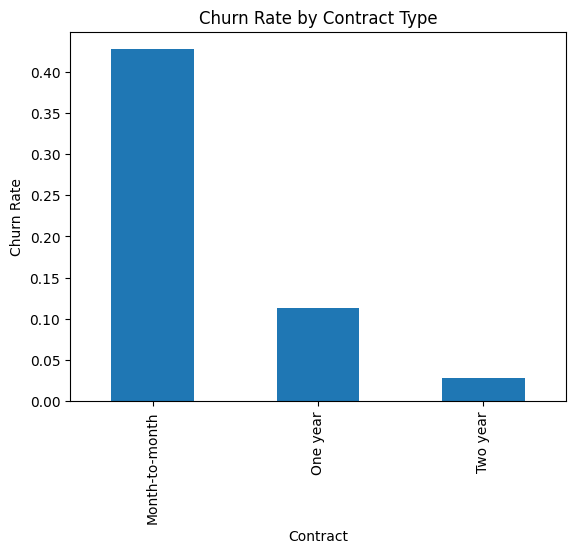

In [16]:
df.groupby('Contract')['Churn'].mean().plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.show()

This bar plot illustrates the churn rate across different contract types. It highlights that customers with month-to-month contracts have a significantly higher churn rate compared to those with one-year or two-year contracts.

Monthly Charges Distribution

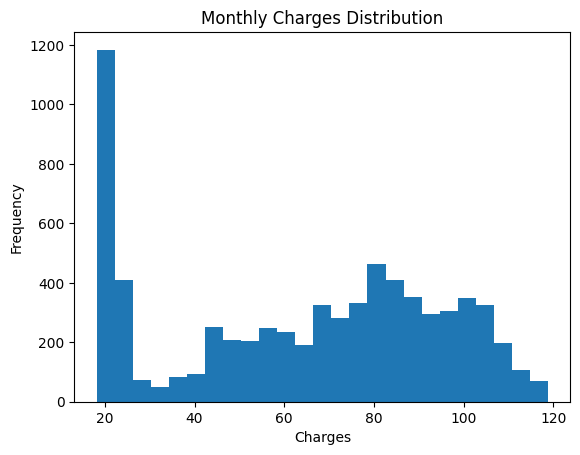

In [17]:
plt.hist(df['MonthlyCharges'], bins=25)
plt.title("Monthly Charges Distribution")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

This histogram displays the distribution of monthly charges among customers. It helps to understand the typical range of monthly charges and identify any patterns or anomalies in pricing.

Churn Rate vs Tenure

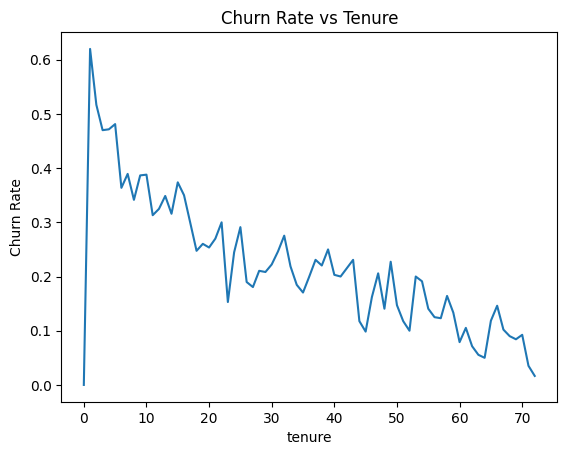

In [20]:
df.groupby('tenure')['Churn'].mean().plot()
plt.title("Churn Rate vs Tenure")
plt.ylabel("Churn Rate")
plt.show()

This line plot shows the relationship between customer tenure (how long they've been a customer) and their churn rate. It suggests that customers with shorter tenures are more likely to churn, and the churn rate generally decreases as tenure increases.

Churn by Internet Service

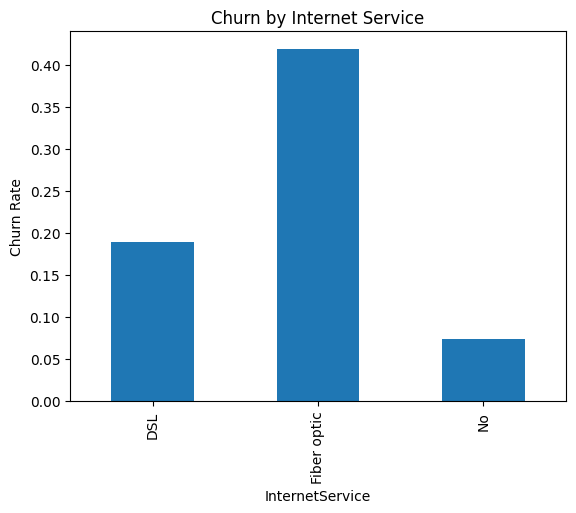

In [21]:
df.groupby('InternetService')['Churn'].mean().plot(kind='bar')
plt.title("Churn by Internet Service")
plt.ylabel("Churn Rate")
plt.show()

This bar plot compares the churn rates for different internet service types. It reveals that customers with Fiber optic internet service have a higher churn rate than those with DSL or no internet service.

Monthly Charges vs Churn Rate

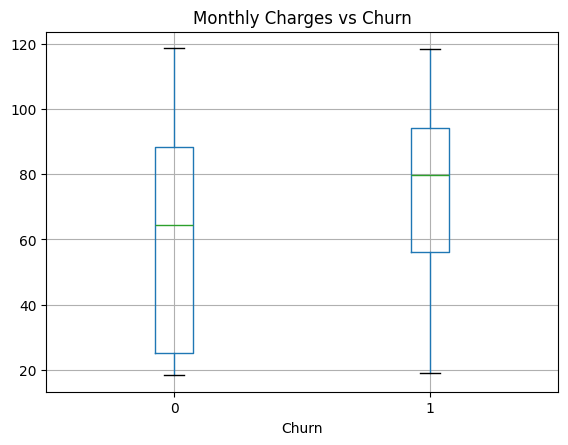

In [22]:
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.show()

This box plot visualizes the distribution of monthly charges for customers who churned versus those who did not. It indicates that customers with higher monthly charges tend to have a higher churn probability, as the median and spread of monthly charges are generally higher for churned customers.

Correlation Heatmap

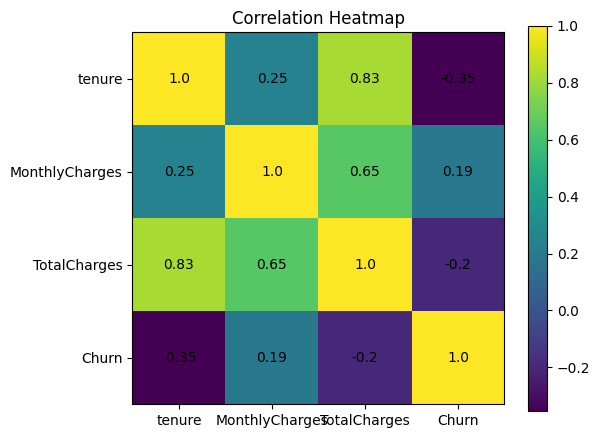

In [24]:
corr = df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr()
plt.figure(figsize=(6,5))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center')

plt.title("Correlation Heatmap")
plt.show()

This heatmap shows the correlation matrix between tenure, MonthlyCharges, TotalCharges, and Churn. It helps to identify the strength and direction of linear relationships between these variables. For instance, tenure and TotalCharges are highly positively correlated, while tenure and Churn are negatively correlated.

**QUESTION 1:-**
Develop a model to predict whether a customer will churn or not based on customer attributes such as tenure, monthly charges, and total charges.

In [25]:
# Feature selection
X = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
y = df['Churn']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7977288857345636


This cell develops a logistic regression model to predict churn based on tenure, MonthlyCharges, and TotalCharges. It splits the data into training and testing sets, trains the model, makes predictions, and then evaluates the model's accuracy. The accuracy of approximately 79.77% indicates the model's predictive capability with these features.

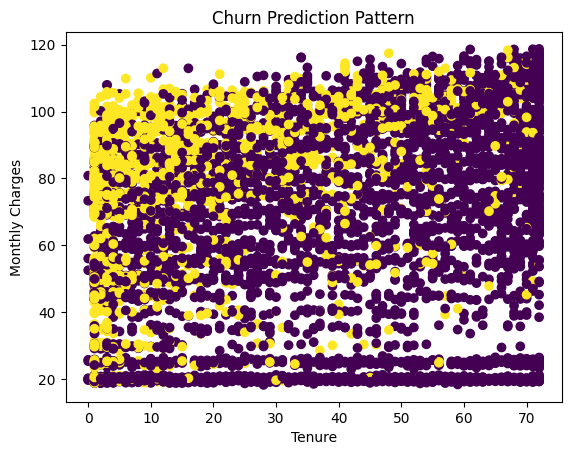

In [27]:
plt.scatter(df['tenure'], df['MonthlyCharges'], c=df['Churn'])
plt.title("Churn Prediction Pattern")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

This scatter plot visualizes the churn pattern based on tenure and MonthlyCharges. Customers are colored by their churn status, allowing for a visual inspection of how these two features differentiate churned from non-churned customers.

**QUESTION 2:-** Analyze the dataset to identify and evaluate the key factors influencing customer churn using statistical and visualization techniques.

In [28]:
print(df.groupby('Contract')['Churn'].mean())
print(df.groupby('PaymentMethod')['Churn'].mean())
print(df.groupby('InternetService')['Churn'].mean())

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64
InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64


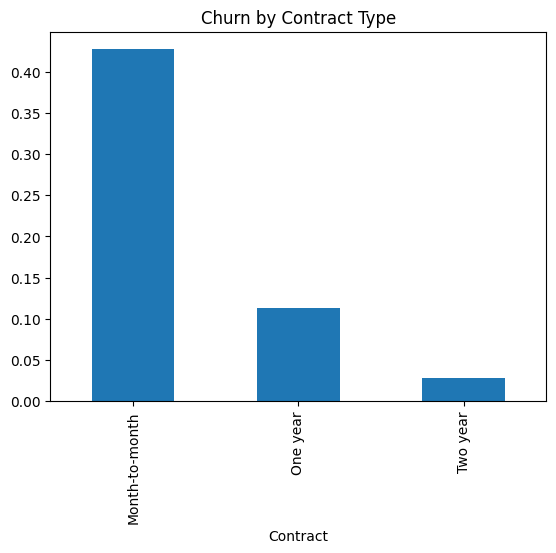

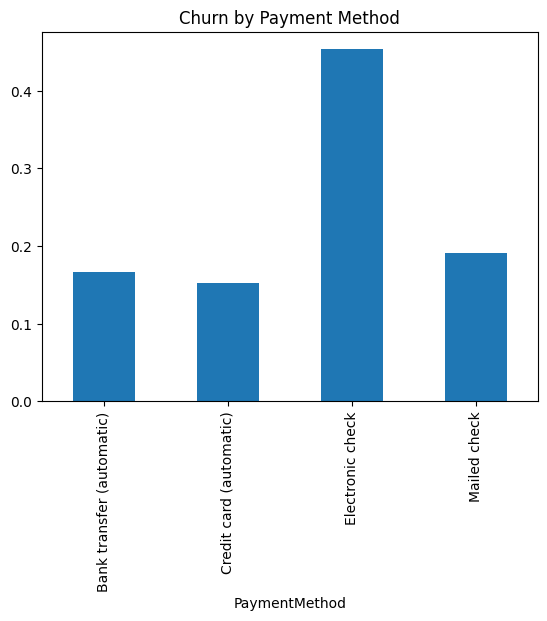

In [29]:
df.groupby('Contract')['Churn'].mean().plot(kind='bar')
plt.title("Churn by Contract Type")
plt.show()

df.groupby('PaymentMethod')['Churn'].mean().plot(kind='bar')
plt.title("Churn by Payment Method")
plt.show()

These bar plots visually represent the churn rates for different contract types and payment methods. They provide clear insights, such as month-to-month contracts and electronic check payments being associated with higher churn.

In [30]:
from scipy.stats import ttest_ind

churn_yes = df[df['Churn']==1]['MonthlyCharges']
churn_no = df[df['Churn']==0]['MonthlyCharges']

t_stat, p_value = ttest_ind(churn_yes, churn_no)

print("P-value:", p_value)

P-value: 2.7066456068884154e-60


**QUESTION 3:-** Segment customers into different groups based on tenure and service usage, and analyze the churn probability within each segment.

In [31]:
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0,12,24,48,72],
                          labels=['0-1yr','1-2yr','2-4yr','4-6yr'])

In [32]:
churn_group = df.groupby('TenureGroup')['Churn'].mean()
print(churn_group)

TenureGroup
0-1yr    0.476782
1-2yr    0.287109
2-4yr    0.203890
4-6yr    0.095132
Name: Churn, dtype: float64


/tmp/ipykernel_14564/665852906.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_group = df.groupby('TenureGroup')['Churn'].mean()


This calculates and prints the average churn rate for each TenureGroup. The output clearly shows that customers in the '0-1yr' group have the highest churn rate, which significantly decreases with longer tenure.

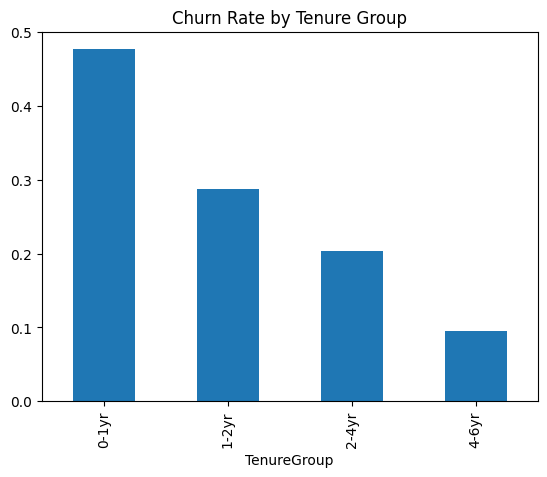

In [33]:
churn_group.plot(kind='bar')
plt.title("Churn Rate by Tenure Group")
plt.show()

This bar plot visualizes the churn rate across the different tenure groups. It graphically confirms the insight that customers with shorter tenures are much more likely to churn.

In [34]:
# High charges condition
high_charge = df[df['MonthlyCharges'] > 70]

prob = len(high_charge[high_charge['Churn']==1]) / len(high_charge)

print("P(Churn | High Charges):", prob)

P(Churn | High Charges): 0.35361428970136755


This calculates the conditional probability of churn given that monthly charges are high (greater than 70). The result indicates that approximately 35.36% of customers with high monthly charges churn, highlighting the significant impact of high charges on churn likelihood.

**CONCLUSION**

This project analyzed and predicted customer churn using the Telco Customer Churn Dataset by applying data cleaning, visualization, statistical analysis, and regression techniques. The results showed that customers with low tenure and high monthly charges are more likely to churn, and statistical testing confirmed that these factors significantly influence customer behavior. Additionally, customers on month-to-month contracts were identified as high-risk groups. The predictive model demonstrated that churn can be effectively estimated using key features, highlighting the importance of data-driven strategies. Overall, the study suggests that improving pricing plans and encouraging long-term customer engagement can help reduce churn and enhance business performance.